In [1]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pydicom as dcm
import math
import os

### Plotting dose and LET as function of depth
Done using water phantom

In [3]:
path = r"C:\Users\bhaan\Downloads\Unrestricted beam plan - LET data and RTStruct\roi_let_dose_coords_cellflask.csv"
data_waterphantom = pd.read_csv(path)
print(data_waterphantom.head())

      x_mm    y_mm    z_mm  LET_keV_per_um  Dose_GyRBE
0 -1.10404 -8.2529 -23.195        1.882960    0.777354
1 -1.07404 -8.2529 -23.195        1.869146    0.777176
2 -1.04404 -8.2529 -23.195        1.874369    0.773880
3 -1.01404 -8.2529 -23.195        1.874030    0.775274
4 -0.98404 -8.2529 -23.195        1.935486    0.782756


In [ ]:
#Take the middle
x_mid = (max(data_waterphantom['x_mm'])-min(data_waterphantom['x_mm']))/2
y_mid = (max(data_waterphantom['y_mm'])-min(data_waterphantom['y_mm']))/2
print(x_mid)

#Extract data with this x and y
d = data_waterphantom[(data_waterphantom['x_mm']==x_mid) & (data_waterphantom['y_mm']==y_mid)]
print(d)

1.11
Empty DataFrame
Columns: [x_mm, y_mm, z_mm, LET_keV_per_um, Dose_GyRBE]
Index: []


In [73]:
#Obtain all z values
z_vals = data['z_mm'].unique()

#Select one z value for a slice
z = z_vals[30]
print(z)

#Isolate slice
slice = data[data['z_mm']==z]

#Set up image array
x_vals = data['x_mm'].unique()
y_vals = data['y_mm'].unique()
imarray = np.zeros([int(len(y_vals)), int(len(x_vals))])

#Populate image array with LET values
for i in range(len(data['x_mm'])):
    datapoint = data.loc[i]
    x = datapoint.x_mm
    y = datapoint.y_mm
    let = datapoint.LET_keV_per_um

    x_index = np.where(x_vals == x)
    y_index = np.where(y_vals == y)

    imarray[y_index, x_index] = let

-25.7


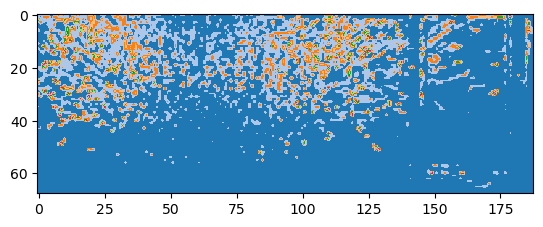

In [74]:
plt.imshow(imarray,cmap='tab20')